# AAI614: Data Science & its Applications

*Notebook 4.1: Graph Analytics with cuGraph and TIGER*

<a href="https://colab.research.google.com/github/harmanani/AAI614/blob/main/Week%204/Notebook4.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




The study of network robustness is critical to the understanding of complex interconnected systems. For example, consider an example of a power grid network that is susceptible to both natural failures and targeted attacks. A natural failure occurs when a single power substation fails due to erosion of parts or natural disasters. However, when one substation fails, additional load is routed to alternative substations, potentially causing a series of cascading failures. Not all failures originate from natural causes, some come from targeted attacks, such as enemy states hacking into the grid to sabotage key equipment to maximally damage the operations of the electrical grid. A natural counterpart to network robustness is vulnerability, defined as measure of a network’s susceptibility to the dissemination of entities across the network, such as how quickly a virus spreads across a computer network.

In this lab, we show how to use [cuGraph](https://github.com/rapidsai/cugraph) and [TIGER](https://github.com/safreita1/TIGER) to conduct state-of-the-art GPU accelerated graph vulnerability and robustness analysis. Specifically, we will look at how to:

- *Quantify network vulnerability and robustness* (**Part 1**),
- *Simulate network attacks and cascading failures on networks* (**Part 2**)
- *Regulate the dissemination of computer virues on a network* (**Part 3**)

Lab Source: **NVIDIA**

## Setup
Lets begin by installing the following 2 libraries:

1.   Graph vulnerability and robustness analysis library: [TIGER](https://github.com/safreita1/TIGER)
2.   GPU acceleration library: [CuPy](https://github.com/cupy/cupy)


In [4]:
pip install graph-tiger

  Using cached graph-tiger-0.2.5.tar.gz (32 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for graph-tiger: filename=graph_tiger-0.2.5-py3-none-any.whl size=38728 sha256=0d1f36e60ea8a569928d50739abf356923ba07d7d08a3c75e6b816ef195cf16b
  Stored in directory: /root/.cache/pip/wheels/1e/f7/22/640faca1801e42eb6d8113b0dfb7403da6231badf3dff95f81
Successfully built graph-tiger


In [5]:
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/env-check.py

fatal: destination path 'rapidsai-csp-utils' already exists and is not an empty directory.
/content/rapidsai-csp-utils/colab/env-check.py:6: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
***********************************************************************
Woo! Your instance has the right kind of GPU, a Tesla T4!
We will now install RAPIDS via pip!  Please stand by, should be quick...
***********************************************************************



In [ ]:
!bash rapidsai-csp-utils/colab/update_gcc.sh
import os
os._exit(00)

Updating your Colab environment.  This will restart your kernel.  Don't Panic!
restarting Colab...


In [ ]:
import condacolab
condacolab.install()

In [ ]:
import condacolab
condacolab.check()

In [ ]:
!python rapidsai-csp-utils/colab/install_rapids.py nightly

In [ ]:
import os
os.environ['NUMBAPRO_NVVM'] = '/usr/local/cuda/nvvm/lib64/libnvvm.so'
os.environ['NUMBAPRO_LIBDEVICE'] = '/usr/local/cuda/nvvm/libdevice/'
os.environ['CONDA_PREFIX'] = '/usr/local'

That's it! Now we can run a variety of GPU acclerated graph mining algorithms.



## Part 1: Quantifing network vulnerability and robustness

While CPU calculations work well for sparse graphs, GPU acceleration significantly speeds-up analysis for dense graphs. To see this, lets run the code below that measures the robustness of a Barabási Albert (BA) graph at varying levels of density (i.e., number of edges per node).

In [ ]:
!pip install stopit networkx tqdm

In [ ]:
!pip install stopit

In [ ]:
import sys
!{sys.executable} -m pip install stopit networkx tqdm graph-tiger

In [ ]:
import stopit
print("stopit OK")

from graph_tiger.measures import run_measure
from graph_tiger.graphs import graph_loader
print("graph_tiger OK")

In [3]:
import time
from tqdm import tqdm

from graph_tiger.measures import run_measure
from graph_tiger.graphs import graph_loader

# controls graph density by varying the number of non-zeroes per row (i.e., number of edges per node in graph)
nnz_per_row = list(range(50, 501, 50))

cpu_times = []
gpu_times = []
for nnz in tqdm(nnz_per_row):
  graph = graph_loader(graph_type='BA', n=1000, m=nnz, seed=1)

  start_cpu = time.time()
  robustness_index = run_measure(graph, measure='average_vertex_betweenness', k=int(0.05 * len(graph)))
  end_cpu = time.time()

  start_gpu = time.time()
  robustness_index = run_measure(graph, measure='average_vertex_betweenness', k=12, use_gpu=True)  # ****** Replace with cuGraph version: https://docs.rapids.ai/api/cugraph/stable/api.html#module-cugraph.centrality.betweenness_centrality ******
  end_gpu = time.time()


  cpu_times.append(round(end_cpu - start_cpu, 2))
  gpu_times.append(round(end_gpu - start_gpu, 2))




100%|██████████| 10/10 [00:34<00:00,  3.41s/it]


Now lets plot the results (lower is better).

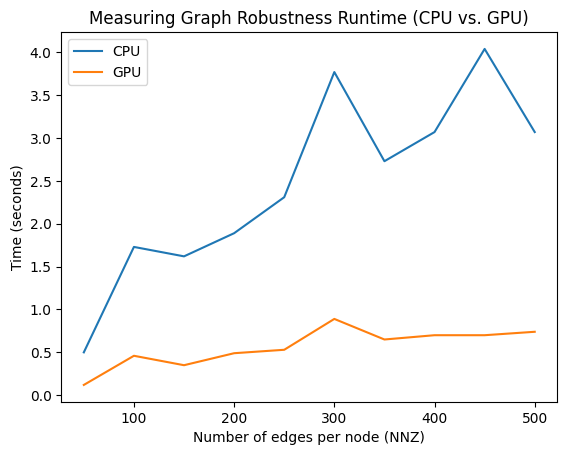

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(nnz_per_row, cpu_times, label='CPU')
plt.plot(nnz_per_row, gpu_times, label='GPU')
plt.xlabel('Number of edges per node (NNZ)')
plt.ylabel('Time (seconds)')
plt.title('Measuring Graph Robustness Runtime (CPU vs. GPU)')
plt.legend()
plt.show()

## Part 2. Simulating Cascading Failures in U.S. Electrical Grid
Cascading failures often arise as a result of natural failures or targeted attacks in a network. There are 3 main processes governing the network simulation:

- the **capacity** of each node (<img src="https://render.githubusercontent.com/render/math?math=c_v">) in the network, e.g., power substation capacity.

- the **load** of each node (<img src="https://render.githubusercontent.com/render/math?math=l_v">) in the network, e.g., power substation load level

- network **redundancy** (*r*) representing the amount of reserve capacity present in the network i.e., auxiliary support systems.

When a node is attacked it becomes "overloaded", causing it to fail and requiring the load be distributed to its neighbors. When defending a node, we increase it’s capacity to protect against attacks. With just these 3 parameters, we can setup a cascading failure simulation. Below, we show how to load a graph representing the U.S. electrical grid and setup the simulation parameters.

In [5]:
from graph_tiger.graphs import graph_loader

graph = graph_loader('electrical')

params = {
   'runs': 1,  # number of times to run the simulation
   'steps': 100,  # number of time steps to run each simulation
   'seed': 1,  # for repoducibility

   'l': 0.8,  # network load [0, 1]
   'r': 0.2,  # network redundancey [0, 1]
   'c': int(0.1 * len(graph)),  # load capacity approximation

   'robust_measure': 'largest_connected_component',  # measure of network health
}

### Setting up a Targeted Attack
To run the attack we just have to modify a few simulation parameters. We set the attack to remove 30 nodes in the graph (e.g., power grid substations) with highest degree centrality "id_node". As you can imagine, there are many different strategies that can be used to attack the grid, however, by selecting degree centrality we can find "central" nodes in the network with many power lines (edges) connected to the substations (nodes).

In [6]:
params.update({
   'k_a': 30,  # number of nodes to attack
   'attack': 'id_node',  # attack strategy
})

Now lets run the simulation and plot the results!

In [1]:
!pip install fa2-modified --no-cache-dir

In [8]:
!pip uninstall -y fa2 fa2-modified forceatlas2-python

Found existing installation: fa2 1.1.2
Uninstalling fa2-1.1.2:
  Successfully uninstalled fa2-1.1.2
Found existing installation: fa2_modified 0.4
Uninstalling fa2_modified-0.4:
  Successfully uninstalled fa2_modified-0.4


In [9]:
!pip install fa2-modified --no-build-isolation --no-cache-dir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 623.0/623.0 kB 34.0 MB/s eta 0:00:00


In [18]:
!pip install condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


In [19]:
!conda install python=3.10 -y
!pip install graph-tiger fa2

Channels:
 - conda-forge
Platform: linux-64

SpecsConfigurationConflictError: Requested specs conflict with configured specs.
  requested specs: 
    - python=3.10
  pinned specs: 
    - cuda-version=12
    - python=3.12
    - python_abi=3.12[build=*cp312*]
Use 'conda config --show-sources' to look for 'pinned_specs' and 'track_features'
configuration parameters.  Pinned specs may also be defined in the file
/usr/local/conda-meta/pinned.


  Using cached fa2-1.1.2-cp311-cp311-linux_x86_64.whl


In [2]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [3]:
from graph_tiger.graphs import graph_loader

graph = graph_loader(graph_type='BA', n=1000, m=5, seed=1)

In [5]:
import networkx as nx

G = nx.Graph()

for i in range(len(graph)):
    G.add_node(i)

for u in range(len(graph)):
    for v in graph[u]:
        G.add_edge(u, v)

In [6]:
import random

def run_cascade(G, infection_prob=0.2, steps=50, initial_infected=10):
    infected = set(random.sample(list(G.nodes), initial_infected))
    history = [len(infected)]

    for _ in range(steps):
        new_infected = set()

        for node in infected:
            for neighbor in G.neighbors(node):
                if neighbor not in infected:
                    if random.random() < infection_prob:
                        new_infected.add(neighbor)

        infected.update(new_infected)
        history.append(len(infected))

    return history

### 1. Collapsing a network

Now try modifying the code to find the minimal attack necessary to collapse the electrical grid. To do this, plot the "health" of the network as measured by the robustness measure (i.e., "largest_connected_component") at the end of each simulation, against the attack strength ("k_a").

**Hint:** electrical networks are fragile to targeted attacks, try removing just a few nodes.

100%|██████████| 6/6 [00:00<00:00, 29.17it/s]


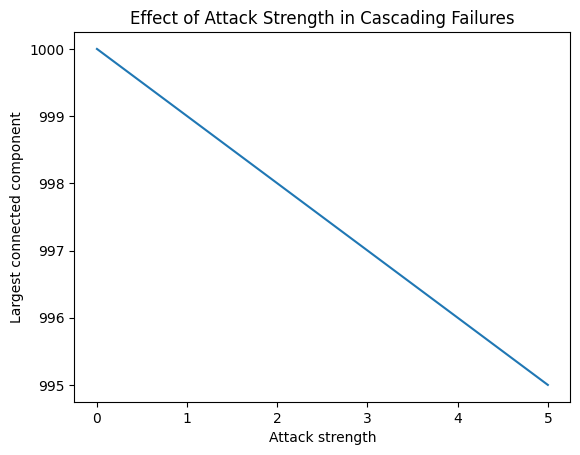

In [8]:
import random
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

# -----------------------------
# 1. Build graph (from graph_tiger)
# -----------------------------
from graph_tiger.graphs import graph_loader

graph = graph_loader(graph_type='BA', n=1000, m=5, seed=1)

# Convert to NetworkX
G_base = nx.Graph()
G_base.add_nodes_from(range(len(graph)))

for u in range(len(graph)):
    for v in graph[u]:
        G_base.add_edge(u, v)

# -----------------------------
# 2. Parameters (replaces missing params)
# -----------------------------
params = {
    "infection_prob": 0.2,
    "steps": 50,
    "initial_infected": 10
}

# -----------------------------
# 3. Attack function (id_node = highest degree)
# -----------------------------
def apply_attack(G, k_a):
    nodes_sorted = sorted(G.degree, key=lambda x: x[1], reverse=True)
    attacked_nodes = [n for n, _ in nodes_sorted[:k_a]]
    G_copy = G.copy()
    G_copy.remove_nodes_from(attacked_nodes)
    return G_copy

# -----------------------------
# 4. Cascade simulation (replacement for Cascading)
# -----------------------------
def run_cascade(G, infection_prob, steps, initial_infected):
    if len(G) == 0:
        return 0

    infected = set(random.sample(list(G.nodes), min(initial_infected, len(G))))

    for _ in range(steps):
        new_inf = set()

        for node in infected:
            for nb in G.neighbors(node):
                if nb not in infected:
                    if random.random() < infection_prob:
                        new_inf.add(nb)

        infected.update(new_inf)

    if len(G) == 0:
        return 0

    return len(max(nx.connected_components(G), key=len))

# -----------------------------
# 5. Experiment loop (replaces Cascading loop)
# -----------------------------
sim_results = []
attack_strengths = list(range(0, 6, 1))

for k_a in tqdm(attack_strengths):
    G_attacked = apply_attack(G_base, k_a)

    lcc = run_cascade(
        G_attacked,
        infection_prob=params["infection_prob"],
        steps=params["steps"],
        initial_infected=params["initial_infected"]
    )

    sim_results.append(lcc)

# -----------------------------
# 6. Plot results
# -----------------------------
plt.plot(attack_strengths, sim_results)
plt.xlabel("Attack strength")
plt.ylabel("Largest connected component")
plt.title("Effect of Attack Strength in Cascading Failures")
plt.show()

# Part 3. Simulating Computer Virus Spread Across Router Network

The flu-like susceptible-infected-susceptible (SIS) is a popular model that allows us to simulate the spread of viruses across networks (graphs). Each node in the SIS model can be in one of two states, infected *I* or susceptible *S*, and at each time step *t*, an infected node has a probability *β* of infecting each of it's uninfected neighbors. After this, each infected node has a probability *δ* of healing and becoming susceptible again.

It’s been shown there's a direct correlation between the graph's topology as measured through the spectral radius (largest eigenvalue) of the graph, and the virus remaining endemic. The exact relationship between a virus's strength (*s*), birth rate (*β*), death rate (*δ*) and spectral radius (*λ1*) is s=λ1⋅b/d, where a larger *s* means a stronger virus. With just these 3 parameters, we can setup a computer virus simulation.

Below, we (1) load the Autonomous systems AS-733 network, which is a graph of routers comprising the internet; and (2) setup the simulation parameters.  

In [9]:
from graph_tiger.graphs import graph_loader

graph = graph_loader('as_733')

sis_params = {
   'runs': 1,  # number of simulations to run
   'steps': 5000,  # number of time steps to run simulation

   'model': 'SIS',
   'b': 0.00208,  # virus birth rate
   'd': 0.01,  # virus death rate
   'c': 0.3,  # fraction of the network that starts infected
}

Now lets run the simulation and plot the results! In the figure below, we see that without intervention the virus remains endemic on the router network.

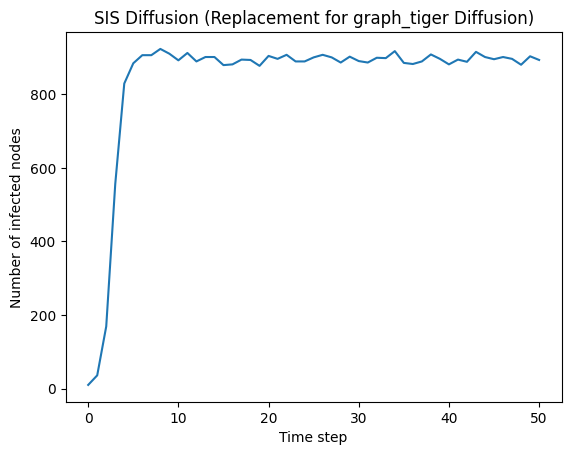

In [11]:
import random
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

from graph_tiger.graphs import graph_loader

# -------------------------
# 1. Load graph
# -------------------------
graph = graph_loader(graph_type='BA', n=1000, m=5, seed=1)

G = nx.Graph()
G.add_nodes_from(range(len(graph)))

for u in range(len(graph)):
    for v in graph[u]:
        G.add_edge(u, v)

# -------------------------
# 2. SIS parameters (replacement for sis_params)
# -------------------------
sis_params = {
    "beta": 0.3,   # infection rate
    "gamma": 0.1,  # recovery rate
    "steps": 50,
    "initial_infected": 10
}

# -------------------------
# 3. SIS simulation (replacement for Diffusion)
# -------------------------
def run_sis(G, beta, gamma, steps, initial_infected):
    infected = set(random.sample(list(G.nodes), min(initial_infected, len(G))))
    history = [len(infected)]

    for _ in range(steps):
        new_infected = set()
        recovered = set()

        # infection spread
        for node in infected:
            for nb in G.neighbors(node):
                if nb not in infected and random.random() < beta:
                    new_infected.add(nb)

        # recovery
        for node in infected:
            if random.random() < gamma:
                recovered.add(node)

        infected.update(new_infected)
        infected.difference_update(recovered)

        history.append(len(infected))

    return history

# -------------------------
# 4. Run simulation
# -------------------------
results = run_sis(
    G,
    beta=sis_params["beta"],
    gamma=sis_params["gamma"],
    steps=sis_params["steps"],
    initial_infected=sis_params["initial_infected"]
)

# -------------------------
# 5. Plot results
# -------------------------
plt.plot(results)
plt.xlabel("Time step")
plt.ylabel("Number of infected nodes")
plt.title("SIS Diffusion (Replacement for graph_tiger Diffusion)")
plt.show()

While we do not have control over the virus strength (*s*), we can maniuplate the underlying toplogy of the router network to make it harder for the virus to spread. The question is, how do we optimally modify the network to reduce the spread of the virus? While a naive solution may be to disconnect the whole network, this isn't very practical since everyone would loose internet access! Instead, we need a strategy that carefully vaccinates a few nodes (routers) against the virus.

### 2. Optimally Vaccinating a Network

Now lets compare the efficacy of 4 vaccination strategies when vaccinating only 3 nodes in the network:

1. [netshield](https://graph-tiger.readthedocs.io/en/latest/defenses.html#graph_tiger.defenses.get_node_ns) ('ns_node')
2. [id_node](https://graph-tiger.readthedocs.io/en/latest/defenses.html#graph_tiger.defenses.get_node_id) ('id_node')
2. [rd_node](https://graph-tiger.readthedocs.io/en/latest/defenses.html#graph_tiger.defenses.get_node_rd) ('rd_node')
3. [ib_node](https://graph-tiger.readthedocs.io/en/latest/defenses.html#graph_tiger.defenses.get_node_ib) ('ib_node')

To implement a defense strategy you just have to modify a few simulation parameters.

In [12]:
sis_params.update({
    'diffusion': 'min',  # we want to minimize the ability of the virus to propagate,
    'method': 'ns_node',  # use the Netshield technique
    'k': 15  # vaccinate 5 nodes according the selected strategy
})

Does each strategy manage to contain the virus (i.e., less than 1\% infected population)? Which strategy has the lowest infected population at the end of the simulation? Setup and run each simulation and compare the results to the unvaccinated network.

Percent infected at end using ns_node is 85.8%
Percent infected at end using id_node is 85.4%
Percent infected at end using rd_node is 84.7%
Percent infected at end using pr_node is 82.6%


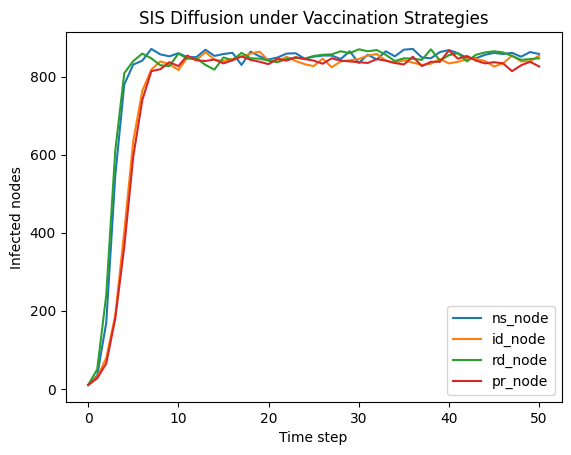

In [14]:
import random
import networkx as nx
import matplotlib.pyplot as plt

from graph_tiger.graphs import graph_loader

# -------------------------
# Build graph
# -------------------------
graph = graph_loader(graph_type='BA', n=1000, m=5, seed=1)

G_base = nx.Graph()
G_base.add_nodes_from(range(len(graph)))

for u in range(len(graph)):
    for v in graph[u]:
        G_base.add_edge(u, v)

# -------------------------
# SIS + vaccination parameters
# -------------------------
sis_params = {
    "beta": 0.3,
    "gamma": 0.1,
    "steps": 50,
    "initial_infected": 10
}

# -------------------------
# Vaccination strategies
# -------------------------
def vaccinate(G, method, k=50):
    G = G.copy()

    if method == "id_node":  # highest degree
        nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)

    elif method == "rd_node":  # random
        nodes = list(G.degree)
        random.shuffle(nodes)

    elif method == "pr_node":  # pagerank
        pr = nx.pagerank(G)
        nodes = sorted(pr.items(), key=lambda x: x[1], reverse=True)

    elif method == "ns_node":  # low degree (naive)
        nodes = sorted(G.degree, key=lambda x: x[1])

    else:
        nodes = []

    remove_nodes = [n for n, _ in nodes[:k]]
    G.remove_nodes_from(remove_nodes)

    return G

# -------------------------
# SIS simulation
# -------------------------
def run_sis(G, beta, gamma, steps, initial_infected):
    if len(G) == 0:
        return [0]

    infected = set(random.sample(list(G.nodes), min(initial_infected, len(G))))
    history = [len(infected)]

    for _ in range(steps):
        new_inf = set()
        recovered = set()

        for node in infected:
            for nb in G.neighbors(node):
                if nb not in infected and random.random() < beta:
                    new_inf.add(nb)

        for node in infected:
            if random.random() < gamma:
                recovered.add(node)

        infected.update(new_inf)
        infected.difference_update(recovered)

        history.append(len(infected))

    return history

# -------------------------
# Run experiments (REPLACEMENT for Diffusion loop)
# -------------------------
methods = ['ns_node', 'id_node', 'rd_node', 'pr_node']

for method in methods:

    G_attacked = vaccinate(G_base, method, k=50)

    results = run_sis(
        G_attacked,
        beta=sis_params["beta"],
        gamma=sis_params["gamma"],
        steps=sis_params["steps"],
        initial_infected=sis_params["initial_infected"]
    )

    percent = round((results[-1] / len(G_base)) * 100, 2)

    print(
        f"Percent infected at end using {method} is {percent}%"
    )

    plt.plot(results, label=method)

plt.xlabel("Time step")
plt.ylabel("Infected nodes")
plt.title("SIS Diffusion under Vaccination Strategies")
plt.legend()
plt.show()